# <center>Homework 103

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

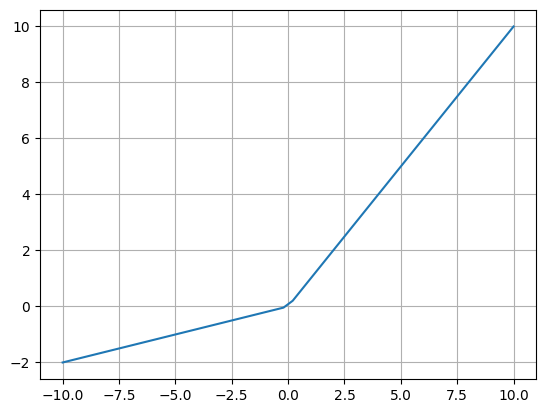

In [6]:
# LeakyReLUα(z) = max(αz, z)

x = np.linspace(-10, 10)

def LeakyReLU(z, alpha=0.2):
    res = z.copy()
    mask = z <= 0
    res[mask] = x[mask] * alpha
    return res

plt.plot(x, LeakyReLU(x))
plt.grid()

In [32]:
X, y = fetch_california_housing(return_X_y=True)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, random_state=42, test_size=0.2, shuffle=True) 
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, random_state=42, test_size=0.1, shuffle=True) 

In [34]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(X_train.shape[1:]),

    tf.keras.layers.Dense(300, kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Dense(100, kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    
    tf.keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.Adam()
model.compile(loss='mse', optimizer=optimizer, metrics=['RootMeanSquaredError'])
model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val))

Epoch 1/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - RootMeanSquaredError: 0.9387 - loss: 0.8812 - val_RootMeanSquaredError: 0.8888 - val_loss: 0.7900
Epoch 2/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 0.7685 - loss: 0.5906 - val_RootMeanSquaredError: 1.0853 - val_loss: 1.1778
Epoch 3/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 0.7316 - loss: 0.5352 - val_RootMeanSquaredError: 0.7943 - val_loss: 0.6310
Epoch 4/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 0.7048 - loss: 0.4967 - val_RootMeanSquaredError: 1.0417 - val_loss: 1.0851
Epoch 5/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - RootMeanSquaredError: 0.7124 - loss: 0.5075 - val_RootMeanSquaredError: 1.0300 - val_loss: 1.0610
Epoch 6/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 0.7015 - loss: 0.4921 - val_RootMeanSquaredError: 0.8916 - val_loss: 0.7949
Epoch 7/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - RootMeanSquaredError: 0.7019 - los

In [35]:
model.evaluate(X_test, y_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - RootMeanSquaredError: 1.4409 - loss: 2.0761


[2.0760555267333984, 1.440852403640747]

In [38]:
org_pred = model.predict(X_test[:3])
org_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


array([[0.6344634],
       [1.0365818],
       [1.5447072]], dtype=float32)

In [39]:
def bn_convert(model):
    new_layers = []

    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization) and \
                isinstance(new_layers[-1], tf.keras.layers.Dense):
           
            W, b = new_layers[-1].get_weights()
            gamma, beta, mean, var = layer.get_weights()
            eps = layer.epsilon

            W_new = W * (gamma / np.sqrt(var + eps))
            b_new = (b - mean) * (gamma / np.sqrt(var + eps)) + beta
            
            new_layers[-1].set_weights([W_new, b_new])
            continue

        new_layers.append(layer)

    return tf.keras.models.Sequential(new_layers)

In [40]:
new_model = bn_convert(model)
print(new_model.predict(X_test[:3]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
[[0.63446337]
 [1.0365822 ]
 [1.5447074 ]]


In [41]:
org_pred

array([[0.6344634],
       [1.0365818],
       [1.5447072]], dtype=float32)